# SequenceVis

Converts a CSV matrix of position-specific amino acid frequencies into foreground/background sequence data for visualization.

## Overview

This notebook takes a CSV table of amino acid probabilities at positions -5 to +4 (relative to a motif center) and:
1. **Foreground (fg)**: Converts probabilities into a discrete pool of sequences enriched for the motif
2. **Background (bg)**: Generates random sequences with a constraint at position 0 (only S or T)

## Workflow
1. Configure variables at the top of the notebook
2. Fetch source modules directly from GitHub
3. Provide a CSV input (upload your own or generate random)
4. Convert the CSV into foreground/background datasets
5. Export results as `fg.csv` and `bg.csv`

In [7]:
# ============================================================
# Configuration — Edit these variables to customize your run
# ============================================================

# --- Input ---
# Path to the input CSV file (set automatically by the CSV input cell below)
CSV_PATH = "input.csv"

# --- Foreground generation ---
FG_SIZE = 1000        # Number of amino acids sampled per position

# --- Background generation ---
BG_SIZE = 5000        # Number of random background sequences
CHAIN_LENGTH = 10     # Length of each sequence (positions -5 to +4)

# --- Random number generation ---
SEED = 42             # Seed for reproducibility (used when TRUERAND is False)
TRUERAND = True       # If True, uses a non-deterministic seed; if False, uses SEED

# --- Output formatting ---
SIGFIGS = 2           # Decimal places for normalized values

# --- CSV input mode ---
# If True, generates a random input CSV automatically.
# If False, you will be prompted to upload your own CSV file.
GENERATE_RANDOM_INPUT = False

## CSV Input

Provide the input CSV file. You can either upload your own file or generate a random one.

The expected format is a CSV with a `titles` column (amino acid one-letter codes) and numeric columns for each position (-5 to +4).

The input mode is controlled by `GENERATE_RANDOM_INPUT` in the **Configuration** cell above.

In [8]:
import shutil

print('=== CSV Input ===')

if GENERATE_RANDOM_INPUT:
    print('Generating random input CSV...')
    amino_acids = ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']
    data = {'titles': amino_acids}
    half = CHAIN_LENGTH // 2
    for pos in range(-half, half):
        col_name = f'{pos:+d}' if pos != 0 else '0'
        data[col_name] = np.random.dirichlet(np.ones(20), size=1).flatten()
    df = pd.DataFrame(data)
    df.to_csv('input.csv', index=False)
    print('Generated random input.csv')
else:
    from google.colab import files
    print('Please upload your CSV file...')
    uploaded = files.upload()
    if uploaded:
        for fn in uploaded.keys():
            print(f'Uploaded file: {fn}')
            shutil.copy(fn, 'input.csv')
        print('Saved as input.csv')
    else:
        print('No file uploaded. Falling back to random input...')
        amino_acids = ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']
        data = {'titles': amino_acids}
        half = CHAIN_LENGTH // 2
        for pos in range(-half, half):
            col_name = f'{pos:+d}' if pos != 0 else '0'
            data[col_name] = np.random.dirichlet(np.ones(20), size=1).flatten()
        df = pd.DataFrame(data)
        df.to_csv('input.csv', index=False)
        print('Generated random input.csv')

# Display the input
print('\nInput CSV preview:')
df = pd.read_csv('input.csv')
print(df.head())

=== CSV Input ===
Please upload your CSV file...


Saving real_input.csv to real_input.csv
Uploaded file: real_input.csv
Saved as input.csv

Input CSV preview:
  Unnamed: 0    -5    -4    -3    -2    -1          0         +1        +2  \
0          P  0.86  1.16  2.04  4.15  1.21        NaN  13.008930  0.517466   
1          G  1.07  1.16  1.11  0.26  0.83        NaN   0.125523  1.595970   
2          A  0.86  1.24  1.14  0.65  1.00        NaN   1.804943  0.948466   
3          C  1.20  1.29  1.38  2.09  1.13        NaN   0.537721  1.291487   
4          S  0.91  1.17  1.66  2.17  1.07  15.743338   1.264245  1.623264   

     +3    +4  
0  1.72  0.91  
1  0.92  0.90  
2  0.97  0.83  
3  1.15  1.24  
4  1.64  1.09  


In [9]:
# Create a copy of input.csv as real_input.csv for the module's import-time tests
import shutil
shutil.copy('input.csv', 'real_input.csv')
print('Created real_input.csv (copy of input.csv) for module import tests.')

Created real_input.csv (copy of input.csv) for module import tests.


## Setup

Install required dependencies and fetch source modules from GitHub.

In [10]:
# Install required packages
!pip install pandas numpy -q

In [11]:
import pandas as pd
import numpy as np
import sys, os, subprocess

## Fetch Source Modules from GitHub

The cells below download the source `.py` files directly from the [sequenceVis GitHub repository](https://github.com/CrankyTitanO7/sequenceVis).

This means the notebook **always stays in sync** with the source code — when the repo is updated, just re-run these cells to get the latest version.

In [12]:
# Fetch biology.py (amino acid alphabet)
!wget -q -O biology.py https://raw.githubusercontent.com/CrankyTitanO7/sequenceVis/main/biology.py
!echo 'biology.py:' && head -3 biology.py

biology.py:
# amino alphabet
AMINO_ALPH = ["A","C","D","E","F","G","H","I","K","L","M","N","P","Q","R","S","T","V","W","Y"]
AMINOS = 20

In [13]:
# Fetch csv-to-fgbg.py (core conversion logic)
!wget -q -O csv_to_fgbg.py https://raw.githubusercontent.com/CrankyTitanO7/sequenceVis/main/csv-to-fgbg.py
!echo 'csv_to_fgbg.py:' && wc -l csv_to_fgbg.py

csv_to_fgbg.py:
133 csv_to_fgbg.py


## Import Modules

Import the fetched source modules. The module's import-time tests will run automatically using `real_input.csv`.

In [14]:
# Import the fetched modules
import biology
print('biology loaded:', biology.AMINO_ALPH[:3], '...')

import csv_to_fgbg
print('csv_to_fgbg loaded')
print('  Functions:', [x for x in dir(csv_to_fgbg) if not x.startswith('_')])

biology loaded: ['A', 'C', 'D'] ...
////////////// foreground generator tests //////////////
     sequence -5 -4 -3 -2 -1  0 +1 +2 +3 +4
0  RNYVTSSIPC  R  N  Y  V  T  S  S  I  P  C
1  RWCCNSPKHY  R  W  C  C  N  S  P  K  H  Y
2  QMYPTTPFTN  Q  M  Y  P  T  T  P  F  T  N
3  QCLGYSPRMS  Q  C  L  G  Y  S  P  R  M  S
4  YDWNCSSRKT  Y  D  W  N  C  S  S  R  K  T

////////////// background generator tests //////////////
['SNIHSTRWRP', 'PYKHATLRDD', 'PIGCCTTIIN', 'QVRPSTLLLL', 'KIQQSSLCRM', 'CNCPASFKNP', 'PSINHSSGGE', 'ATRNYSSDGH', 'KVQEPSFNKF', 'SCNDGTMKFA']... and etc
//////////////       tests  concluded     //////////////

csv_to_fgbg loaded
  Functions: ['AMINOS', 'AMINO_ALPH', 'BG_SIZE', 'CHAIN_LENGTH', 'FG_SIZE', 'PATH', 'SEED', 'SIGFIGS', 'TRUERAND', 'bg', 'bg_dat', 'csv_to_quantity', 'fg', 'fg_dat', 'fg_generate_compiled_sequence', 'fill_blanks', 'norm', 'normalize', 'np', 'open_csv', 'pd', 'rng']


In [15]:
# Apply user configuration to the csv_to_fgbg module
csv_to_fgbg.PATH = CSV_PATH
csv_to_fgbg.FG_SIZE = FG_SIZE
csv_to_fgbg.BG_SIZE = BG_SIZE
csv_to_fgbg.CHAIN_LENGTH = CHAIN_LENGTH
csv_to_fgbg.SEED = SEED
csv_to_fgbg.TRUERAND = TRUERAND
csv_to_fgbg.SIGFIGS = SIGFIGS

# Recreate the random number generator with the new seed settings
csv_to_fgbg.rng = np.random.default_rng(seed=None if TRUERAND else SEED)

print('Configuration applied:')
print(f'  PATH = {csv_to_fgbg.PATH}')
print(f'  FG_SIZE = {csv_to_fgbg.FG_SIZE}')
print(f'  BG_SIZE = {csv_to_fgbg.BG_SIZE}')
print(f'  CHAIN_LENGTH = {csv_to_fgbg.CHAIN_LENGTH}')
print(f'  SEED = {csv_to_fgbg.SEED}')
print(f'  TRUERAND = {csv_to_fgbg.TRUERAND}')
print(f'  SIGFIGS = {csv_to_fgbg.SIGFIGS}')

Configuration applied:
  PATH = input.csv
  FG_SIZE = 1000
  BG_SIZE = 5000
  CHAIN_LENGTH = 10
  SEED = 42
  TRUERAND = True
  SIGFIGS = 2


## 2. Run the Conversion

Execute the foreground and background generators from the fetched source modules.

All parameters (PATH, FG_SIZE, BG_SIZE, CHAIN_LENGTH, SEED, TRUERAND, SIGFIGS) are configured in the **Configuration** cell at the top of the notebook.

- **Foreground (fg)**: Each position's amino acid probabilities are converted into a discrete pool of 1000 amino acids. Then all 10 positions are compiled into a single sequence string.
- **Background (bg)**: 5000 random 10-mer sequences are generated, with position 0 constrained to only S or T.

Output:
- `fg_full.csv` — full foreground with all columns (sequence + each position)
- `fg.csv` — just the compiled sequence column
- `bg.csv` — background sequences

In [16]:
fg_dat = csv_to_fgbg.fg_generate_compiled_sequence()
print("////////////// foreground generator tests //////////////")
fg_dat.head()

////////////// foreground generator tests //////////////


,sequence,-5,-4,-3,-2,-1,0,+1,+2,+3,+4
0,DGVSKSPHTG,D,G,V,S,K,S,P,H,T,G
1,DVSCVSSRWL,D,V,S,C,V,S,S,R,W,L
2,YNPTSSPRWW,Y,N,P,T,S,S,P,R,W,W
3,WPVTNSAGCV,W,P,V,T,N,S,A,G,C,V
4,QNAPLSPRIW,Q,N,A,P,L,S,P,R,I,W


In [17]:
bg_dat = csv_to_fgbg.bg()
print("\n////////////// background generator tests //////////////")
print(bg_dat["bg"].head(10).tolist(), end="... and etc\n")
print("//////////////       tests  concluded     //////////////\n")


////////////// background generator tests //////////////
['KIWQLSLAYF', 'GRMSWSADGV', 'GNLQETTMCY', 'GMYFNSSPAC', 'SMLEHSSTCT', 'LKPDFSLEMD', 'FYALLSRTPS', 'PSHRKTESGG', 'AGWAATFISQ', 'DAPLPSDYHP']... and etc
//////////////       tests  concluded     //////////////



## 3. Export Results

Save the foreground and background data to CSV files and download them.

In [18]:
bg_dat.to_csv("bg.csv", index=False)
fg_dat.to_csv("fg_full.csv", index=False)
fg_dat.iloc[:, [0]].to_csv("fg.csv", index=False)
print("Exported fg.csv, fg_full.csv, and bg.csv")

Exported fg.csv, fg_full.csv, and bg.csv


In [19]:
from google.colab import files

files.download("fg.csv")
files.download("fg_full.csv")
files.download("bg.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 4. Visualization with Logomaker

This section installs `logomaker` and creates a sequence logo to visualize the motif found in the foreground dataset compared to the background.

In [20]:
!pip install logomaker -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.2/13.2 MB 44.1 MB/s eta 0:00:00


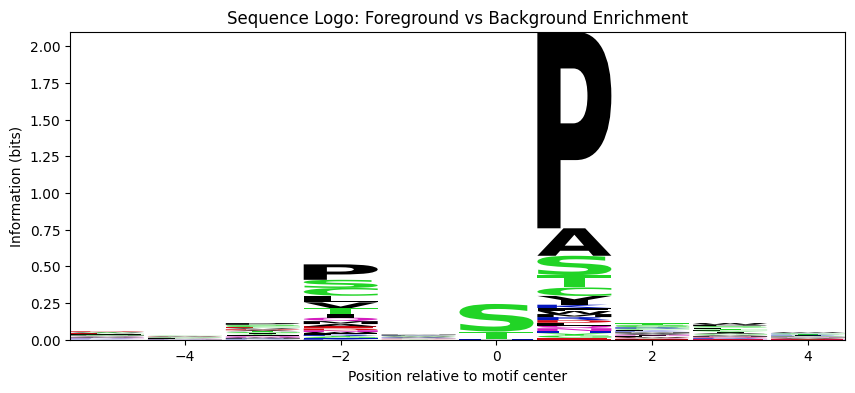

In [21]:
import logomaker
import matplotlib.pyplot as plt

# Helper to convert a list of sequences into a counts matrix
def sequences_to_counts(sequences):
    # Extract position columns
    length = len(sequences[0])
    amino_acids = "ACDEFGHIKLMNPQRSTVWY"
    counts_df = pd.DataFrame(0, index=range(length), columns=list(amino_acids))

    for seq in sequences:
        for i, char in enumerate(seq):
            if char in counts_df.columns:
                counts_df.loc[i, char] += 1
    return counts_df

# 1. Prepare data
fg_sequences = fg_dat['sequence'].tolist()
bg_sequences = bg_dat['bg'].tolist()

fg_counts = sequences_to_counts(fg_sequences)
bg_counts = sequences_to_counts(bg_sequences)

# 2. Create the Probability matrices
fg_prob = logomaker.transform_matrix(fg_counts, from_type='counts', to_type='probability')
bg_prob = logomaker.transform_matrix(bg_counts, from_type='counts', to_type='probability')

# 3. Calculate Information Content (Enrichment)
# FIX: Added from_type='probability' so logomaker knows the input format
logo_df = logomaker.transform_matrix(fg_prob,
                                    from_type='probability',
                                    background=bg_prob,
                                    to_type='information')
logo_df.index = range(-5, 5)

# 4. Plot
fig, ax = plt.subplots(figsize=(10, 4))
logo = logomaker.Logo(logo_df, ax=ax, color_scheme='weblogo_protein')

ax.set_ylabel('Information (bits)')
ax.set_xlabel('Position relative to motif center')
ax.set_title('Sequence Logo: Foreground vs Background Enrichment')
plt.show()

## Summary

- **`fg.csv`**: Foreground dataset — one column with compiled 10-mer sequences. Each sequence's amino acids at each position match the input probabilities scaled to 1000 samples.
- **`fg_full.csv`**: Same foreground data but with all position columns (-5 to +4) included for inspection.
- **`bg.csv`**: Background dataset — 5000 random 10-mer sequences with position 0 constrained to S/T.

These files can be used for downstream motif visualization (e.g., sequence logos, position weight matrices, etc.).

---

> **Note**: The source modules (`biology.py`, `csv_to_fgbg.py`, `random_input.py`) are fetched fresh from GitHub each time the setup cells are re-run. This keeps the notebook automatically in sync with the repository.